In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from typing import Dict, Tuple, Literal, List
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator, MultipleLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import os
from scipy.stats import chi2
os.environ['PATH'] = f"/Library/TeX/texbin:{os.environ['PATH']}"
rc('text', usetex=True)
plt.rcParams['text.usetex'] = True
rc('font', **{'family': 'serif'})
plt.rcParams.update({'font.size': 20})

In [76]:
# Folder where the files are stored
folderpath = "/Users/martines/Desktop/PhD/USMEFT-HL-LHC/Data/ChiSquare"

# Coeffients to plot
wilson_coef = [
    "CBW", "Cphi1", "Delta4F", "C2JB", "C3W2H4", "C7psi4H2", "C2psi4D2", "C3psi4D2"
]

# Different EFT truncations
eft_order = ["d6", "d6sq", "d8"]

contains = {
    "d6": ["CBW", "Cphi1", "Delta4F", "C2JB"],
    "d6sq": ["CBW", "Cphi1", "Delta4F", "C2JB"],
    "d8": ["CBW", "Cphi1", "Delta4F", "C2JB", "C3W2H4", "C7psi4H2", "C2psi4D2", "C3psi4D2"]
}

# Loads the chi-square values for each of coefficients
chi_sq_proj = {
    coef: {
        order: np.transpose(np.loadtxt(f"{folderpath}/{order}/{coef}.dat"))
        for order in eft_order if coef in contains[order]
    }
    for coef in wilson_coef
}

# x limits for each coefficient
x_limits = {
    "CBW":   [-0.002, 0.002],
    "Cphi1": [-0.006, 0.006],
    "Delta4F": [-0.0001, 0.0001],
    "C2JB": [-0.01, 0.01],
    "C3W2H4": [-0.003, 0.003],
    "C7psi4H2": [-0.2, 0.2],
    "C2psi4D2": [-0.002, 0.00005],
    "C3psi4D2": [-0.00002, 0.00002]
}

xaxis_labels = {
        "CBW": r"$10^3 \times \overline{c}_{BW} \frac{\hat{v}^2 }{\Lambda^2}$",
        "Cphi1": r"$10^3 \times \overline{c}_{\phi, 1}\frac{\hat{v}^2 }{\Lambda^2}$",
        "Delta4F": r"$10^4 \times \overline{\Delta}_{4F} \frac{\hat{v}^2 }{\Lambda^2}$",
        "C2JB": r"$10^2 \times  \overline{c}_{2JB}\frac{\hat{v}^2}{\Lambda^2}$",
        "C3W2H4": r"$10^3 \times c_{W^2 H^4}^{(3)}\frac{\hat{v}^4 }{\Lambda^4}$",
        "C7psi4H2": r"$10 \times c^{(7)}_{\psi^4 H^2}\frac{\hat{v}^4 }{\Lambda^4}$",
        "C2psi4D2": r"$10^3 \times c^{(2)}_{\psi^4 D^2}\frac{\hat{v}^4 }{\Lambda^4}$",
        "C3psi4D2": r"$10^5 \times c^{(3)}_{\psi^4 D^2}\frac{\hat{v}^4 }{\Lambda^4}$"
}

colors = {
    "d8": "red",
    "d6": "blue",
    "d6sq": "black"
}

linestyle = {
    "d8": "solid",
    "d6": "solid",
    "d6sq": "dashed"
}

legends = {
    "d8": r"EWPO + CCDY + NCDY (3 ab$^{-1}$) $(d=8)$",
    "d6": r"EWPO + CCDY + NCDY (3 ab$^{-1}$) $(d=6)$",
    "d6sq": r"EWPO + CCDY + NCDY (3 ab$^{-1}$) $(d=6)^2$",
}
    
power = {
        "CBW": 3,
        "Cphi1": 3,
        "C2JB": 2,
        "Delta4F": 4,
        "C3W2H4": 3,
        "C7psi4H2": 1,
        "C2psi4D2": 3,
        "C3psi4D2": 5
    }
d6coefs = ["CBW", "Cphi1", "C2JB", "Delta4F"]
vev = 0.246

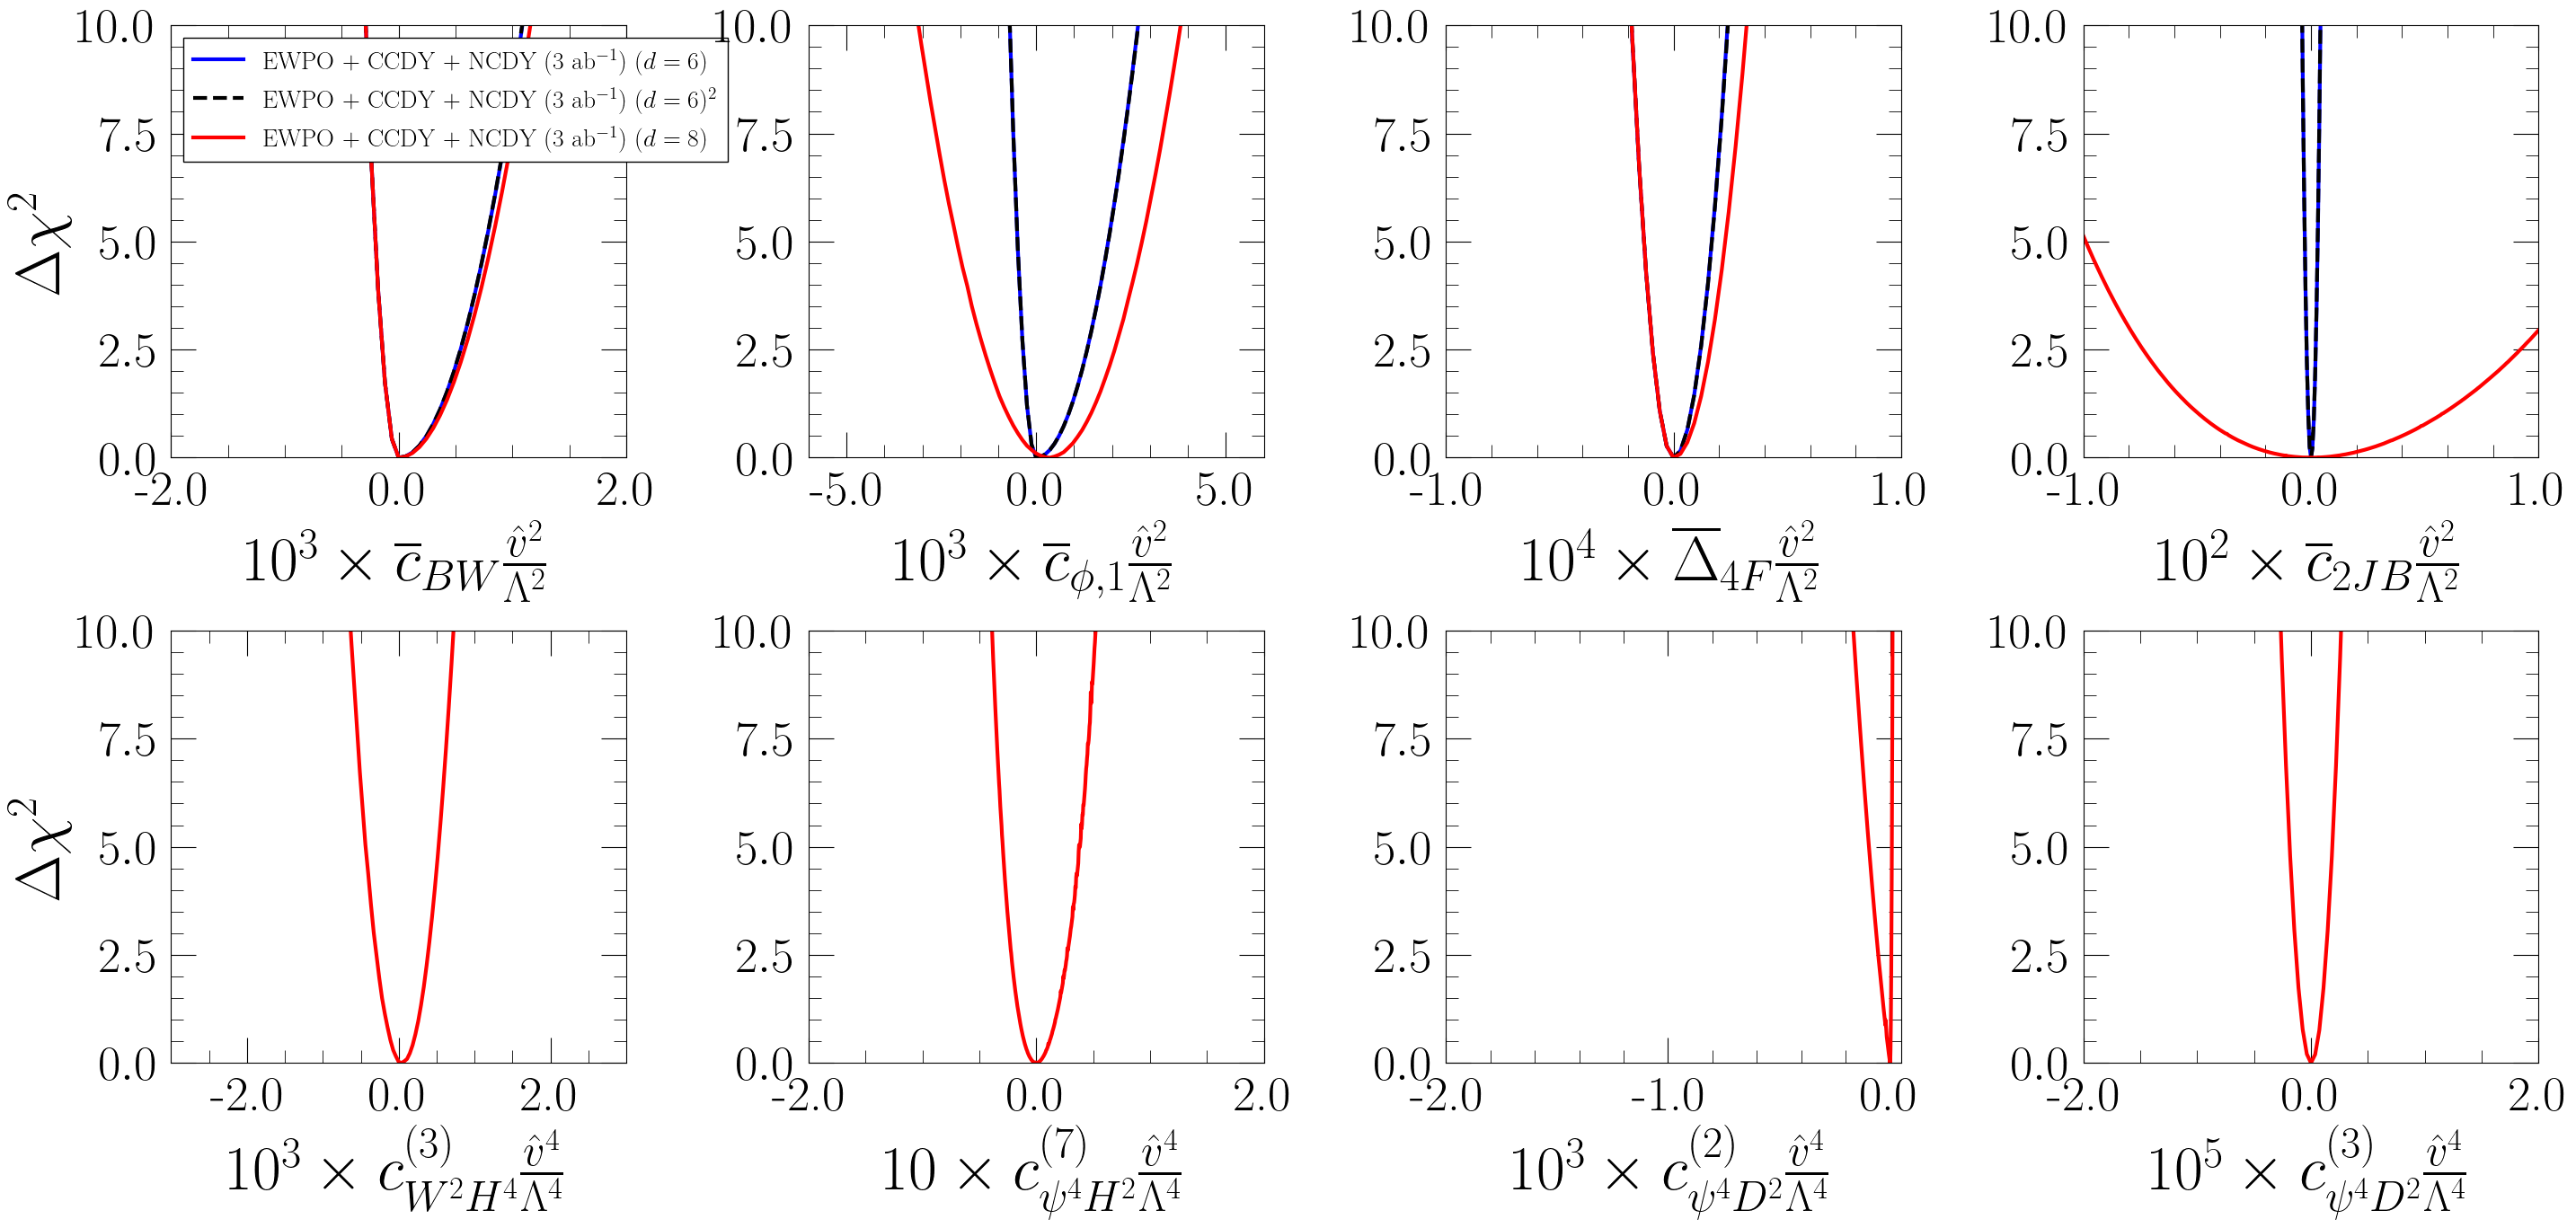

In [77]:
# definfing the frame
fig, ax = plt.subplots(nrows=2, ncols=4, squeeze=False, figsize=(34, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

def make_formatter(exp):
    """Creates a formatter function that scales axis values by 10^exp."""
    return FuncFormatter(lambda val, pos: f"{val * 10 ** exp:.1f}")
    
# Panel indices
row, column = 0, 0

# Iterates over all the subplots
for index_plot, coef_name in enumerate(chi_sq_proj):
    # Settings
    ax[row, column].set_xlim(*x_limits[coef_name])
    ax[row, column].set_ylim(0, 10)
    ax[row, column].tick_params(axis='x', pad=10, labelsize=40)
    ax[row, column].tick_params(axis='y', pad=10, labelsize=40)
    ax[row, column].xaxis.set_minor_locator(AutoMinorLocator())
    ax[row, column].yaxis.set_minor_locator(AutoMinorLocator())
    ax[row, column].tick_params(axis="both", which="minor", top=True, right=True, length=10, direction="in")
    ax[row, column].tick_params(axis="both", which="major", top=True, right=True, length=20, direction="in")
    ax[row, column].set_xlabel(xaxis_labels[coef_name], fontsize=50)
    if column == 0:
        ax[row, column].set_ylabel(r"$\Delta \chi^2$", fontsize=50)
        
    # Plot
    for dist_name, (x_values, chisq) in chi_sq_proj[coef_name].items():
        ax[row, column].plot(
            x_values * np.power(vev, 2 if coef_name in d6coefs else 4), 
            chisq - np.amin(chisq), 
            color=colors[dist_name],
            linestyle=linestyle[dist_name], 
            label=legends[dist_name],
            lw=3
        )
    
    # Apply dynamic formatters
    ax[row, column].xaxis.set_major_formatter(make_formatter(power[coef_name]))
    
    if row == column == 0:
        ax[row, column].legend(fancybox=False, frameon=True, framealpha=1, edgecolor="black", ncols=1,
                               fontsize=20, loc="upper left")
    
    # Updates the indices
    column += 1
    if column >= 4:
        row += 1
        column = 0

plt.savefig(f"{folderpath}/OneDimProj-Concha.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()